In [9]:
!python -m pip install pandas matplotlib seaborn scikit-learn

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [14]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

colunas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv(url, names=colunas)

print("BASE DE DADOS")
print(df.head())

#drop('Outcome', axis=1) → irá remover a coluna chamada Outcome(saída). O axis=1 indica que queremos remover uma coluna (e não linhas).
X = df.drop('Outcome', axis=1)
y = df['Outcome']

BASE DE DADOS
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [21]:
# Dividir treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [22]:
# Modelo Árvore de Decisão

modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

modelo.fit(X_treino, y_treino)
previsoes = modelo.predict(X_teste)

In [23]:
# Avaliação # 
print("\nACURÁCIA")
print(accuracy_score(y_teste, previsoes))

print("\nRELATÓRIO DE CLASSIFICAÇÃO")
print(classification_report(y_teste, previsoes))


ACURÁCIA
0.70995670995671

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

           0       0.85      0.68      0.75       151
           1       0.56      0.78      0.65        80

    accuracy                           0.71       231
   macro avg       0.70      0.73      0.70       231
weighted avg       0.75      0.71      0.72       231



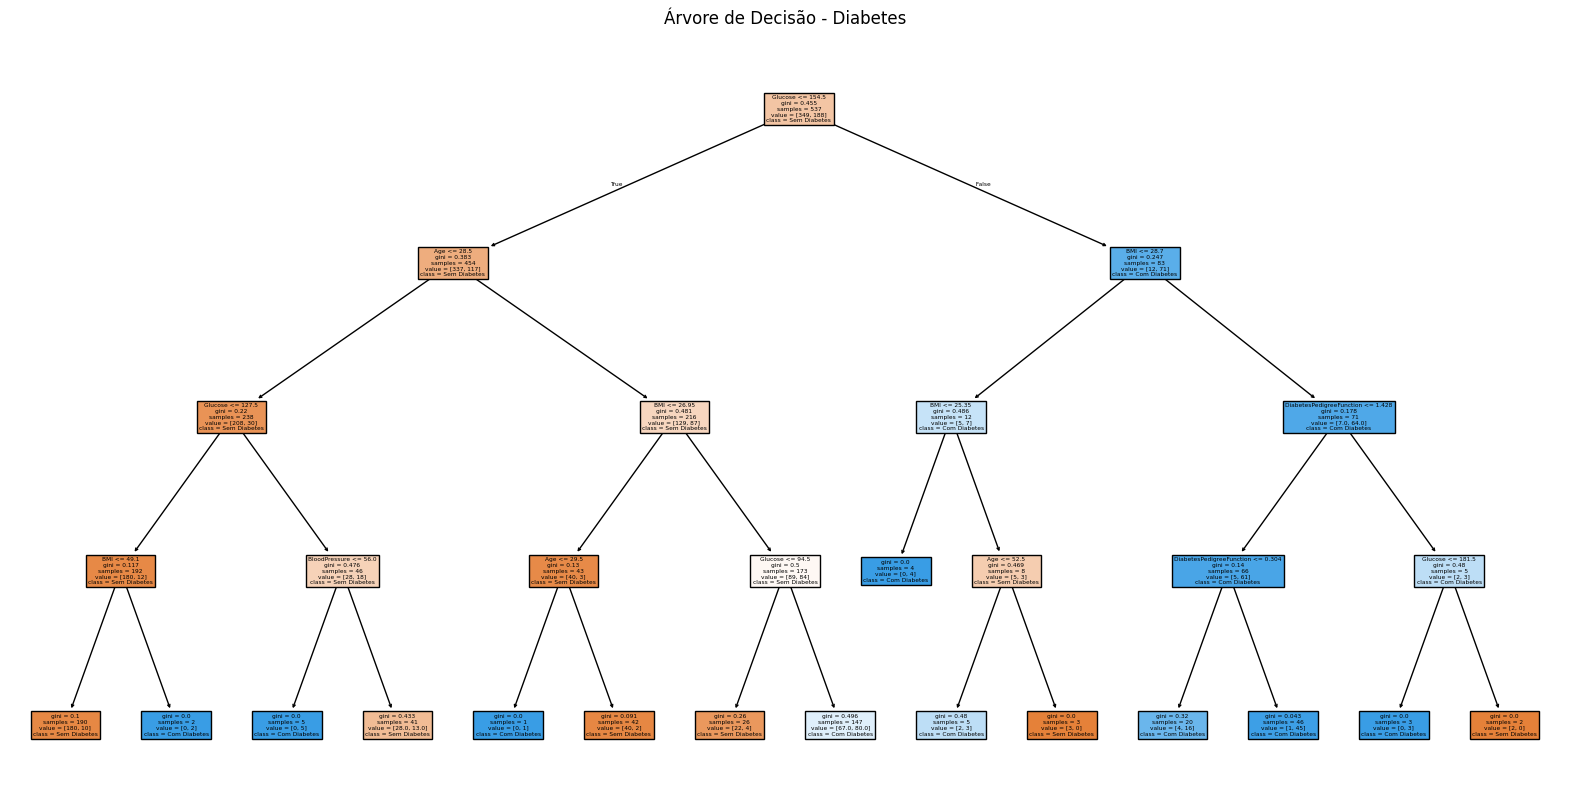

In [24]:
# Árvore de decisão

plt.figure(figsize=(20,10))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=['Sem Diabetes', 'Com Diabetes'],
    filled=True
)

plt.title("Árvore de Decisão - Diabetes")
plt.show()